# Neural Network Classifier Pipeline
This notebook demonstrates the pipeline for training, predicting, and evaluating the provided Neural Network, including calculating AUC and significance metrics.
The dataset is imported directly from the HiggsML package.

In [1]:
!pip install HiggsML

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 8.4 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

import joblib
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.optimizers import Adam

class NeuralNetwork:
    """
    This class implements a neural network classifier.
    """

    def __init__(self, n_dim=None,shared_layer_size = 10, n_layers=4, activation="relu", lr=0.001, dropout=0):
        self.model = None
        self.scaler = StandardScaler()

        if n_dim is not None:
            self.model = Sequential()
            #n_dim = train_data.shape[1]
            self.model.add(tf.keras.Input(shape=(n_dim,)))
            for _ in range(n_layers):
                self.model.add(Dense(shared_layer_size, activation=activation))
                #on n'ajoute le dropout que si le taux est supérieur à 0 pour éviter de faire des calculs inutiles
                if dropout > 0:
                    self.model.add(Dropout(dropout))

            self.model.add(Dense(1, activation="sigmoid"))
        #définition de la méthode d'optimisation (descente de gradient, fonction de perte, et métriques d'évaluation)
        self.model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])

    def fit(self, train_data, y_train, weights_train=None, X_val=None, y_val=None, weights_val=None, epochs=20):
        X_train_scaled = self.scaler.fit_transform(train_data)

        validation_data = None
        if X_val is not None and y_val is not None:
            X_val_scaled = self.scaler.transform(X_val)
            if weights_val is not None:
                validation_data = (X_val_scaled, y_val, weights_val)
            else:
                validation_data = (X_val_scaled, y_val)

        history = self.model.fit(
            X_train_scaled, y_train,
            sample_weight=weights_train,
            validation_data=validation_data,
            batch_size=2048,  # On augmente le batch_size car le GPU adore les gros blocs !
            epochs=epochs,
            verbose=0
        )
        self.history = history   # store history as an instance attribute
        return history   # permet de conserver des données pour le tracé des courbes d'apprentissage

    def predict(self, test_data, labels=None, weights=None):
        test_data = self.scaler.transform(test_data)
        predictions = self.model.predict(test_data).flatten().ravel()

        # Store predictions for significance calculation
        self.__predicted_data = predictions
        # Optionally store test labels and weights if provided
        if labels is not None:
            self.__test_labels = labels
        if weights is not None:
            self.__test_weights = np.asarray(weights)
        return predictions

    def significance(self, test_labels=None, test_weights=None):
        if test_labels is not None:
            self.__test_labels = test_labels
        if test_weights is not None:
            self.__test_weights = test_weights
        if self.__test_labels is None:
            raise ValueError(
                "True labels for test data are not available. Please provide them when calling predict()."
            )

        def __amsasimov(s_in, b_in):
            s = np.copy(s_in)
            b = np.copy(b_in)
            s = np.where((b_in == 0), 0.0, s_in)
            b = np.where((b_in == 0), 1.0, b)
            ams = np.sqrt(2 * ((s + b) * np.log(1 + s / b) - s))
            ams = np.where((s < 0) | (b < 0), np.nan, ams)
            if np.isscalar(s_in):
                return float(ams)
            else:
                return ams

        def __significance_vscore(y_true, y_score, sample_weight=None):
            if sample_weight is None:
                sample_weight = np.full(len(y_true), 1.0)
            else:
                sample_weight = np.asarray(sample_weight)
            bins = np.linspace(0, 1.0, 101)
            s_hist, _ = np.histogram(
                y_score[y_true == 1], bins=bins, weights=sample_weight[y_true == 1]
            )
            b_hist, _ = np.histogram(
                y_score[y_true == 0], bins=bins, weights=sample_weight[y_true == 0]
            )
            s_cumul = np.cumsum(s_hist[::-1])[::-1]
            b_cumul = np.cumsum(b_hist[::-1])[::-1]
            significance = __amsasimov(s_cumul, b_cumul)
            return significance

        vamsasimov_xgb = __significance_vscore(
            y_true=self.__test_labels,
            y_score=self.__predicted_data,
            sample_weight=self.__test_weights,
        )

        plt.plot(np.linspace(0, 1.0, 100), vamsasimov_xgb, label="AMS Significance")
        plt.xlabel("Score")
        plt.ylabel("Significance")
        return np.max(vamsasimov_xgb)


    def plot_learning_curves(self):
        if not hasattr(self, "history"):
            raise ValueError("Le modèle doit être entraîné avant de tracer les courbes.")   #permet de tracer les courbes uniquement pour un modèle entrainé
        plt.figure(figsize=(10, 5))
        plt.plot(self.history.history["loss"], label="Loss (train)")
        if "val_loss" in self.history.history:
            plt.plot(self.history.history["val_loss"], label="Loss (val)")
        plt.plot(self.history.history["accuracy"], label="Accuracy (train)")
        if "val_accuracy" in self.history.history:
            plt.plot(self.history.history["val_accuracy"], label="Accuracy (val)")
        plt.xlabel("Epochs")
        plt.ylabel("Score")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_score_distribution(self, X_test, y_test):
        # Predict on the test set
        y_pred = self.predict(X_test)

        # Séparer les scores de signal (y_test=1) et de background (y_test=0)
        signal_scores = y_pred[y_test == 1]
        bkg_scores = y_pred[y_test == 0]

        # Tracer les distributions avec Matplotlib
        plt.figure(figsize=(8, 6))
        plt.hist(signal_scores, bins=50, alpha=0.5, label='Signal', color='blue', density=True)
        plt.hist(bkg_scores, bins=50, alpha=0.5, label='Background', color='red', density=True)

        # Ajouter les détails au graphique
        plt.title('Score Distribution (Signal vs Background)')
        plt.xlabel('Prediction Score')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(True)
        plt.show()

    def save_model(self, path):
        """Save the trained model and scaler to the specified path."""
        if not os.path.exists(path):
            os.makedirs(path)
        model_path = os.path.join(path, "model.h5")
        self.model.save(model_path)
        print(f"Model saved to {model_path}")

        scaler_path = os.path.join(path, "scaler.pkl")
        joblib.dump(self.scaler, scaler_path)
        print(f"Scaler saved to {scaler_path}")

    def load_model(self, path):
        """Load the trained model and scaler from the specified path."""
        model_path = os.path.join(path, "model.h5")
        self.model = load_model(model_path)
        print(f"Model loaded from {model_path}")

        scaler_path = os.path.join(path, "scaler.pkl")
        self.scaler = joblib.load(scaler_path)
        print(f"Scaler loaded from {scaler_path}")







### Load Data
We will load data based on the actual physical distributions from HiggsML.

In [3]:
COLAB = "google.colab" in str(get_ipython())
if COLAB:
    !rm -rf Higgs_collaborations
    !git clone https://github.com/blackSwanCS/Higgs_collaborations.git
    %cd Higgs_collaborations
# HiggsML utility package should not be modified
%pip install HiggsML==0.1.5
import numpy as np
import HiggsML
from HiggsML.datasets import download_dataset

data = download_dataset(
    "blackSwan_data"
)
data.load_train_set()
data_set = data.get_train_set()
print(data_set.columns)



from sklearn.model_selection import train_test_split

X = data_set.drop(columns=["labels", "weights", "detailed_labels"])
y = data_set["labels"]
w = data_set["weights"]

SUM_W_SIG = 1_015.0
SUM_W_BKG = 1_050_370.0

def rescale_weights(weights, labels, sum_sig, sum_bkg):
    w = weights.copy().astype(float)
    sig_mask = labels == 1
    bkg_mask = labels == 0
    if w[sig_mask].sum() > 0:
        w[sig_mask] *= sum_sig / w[sig_mask].sum()
    if w[bkg_mask].sum() > 0:
        w[bkg_mask] *= sum_bkg / w[bkg_mask].sum()
    return w

w = rescale_weights(w, y, SUM_W_SIG, SUM_W_BKG)

print(f"Test sum W signal: {w[y==1].sum():.1f}  (expected ~1015)")
print(f"Test sum W bkg:    {w[y==0].sum():.1f}  (expected ~1050370)")

X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X.to_numpy(),
    y.to_numpy(),
    w.to_numpy(),
    train_size=1000,
    test_size=0.2,
    random_state=42,
)


Cloning into 'Higgs_collaborations'...
remote: Enumerating objects: 339, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 339 (delta 62), reused 56 (delta 56), pack-reused 224 (from 1)
Receiving objects: 100% (339/339), 21.55 MiB | 16.11 MiB/s, done.
Resolving deltas: 100% (169/169), done.
/content/Higgs_collaborations
  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


Index(['PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_had_pt', 'PRI_had_eta',
       'PRI_had_phi', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta',
       'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_n_jets',
       'PRI_jet_all_pt', 'PRI_met', 'PRI_met_phi', 'weights',
       'detailed_labels', 'labels', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_had_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_had', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality'],
      dtype='object')
Test sum W signal: 1015.0  (expected ~1015)
Test sum W bkg:    1050370.0  (expected ~1050370)


### HPO with optuna

In [ ]:
!pip install optuna
import optuna

#on a déjà défini les données d'entrainement et de validation globalement, on n'a plus besoin de les charger à chaque essai d'Optuna
import numpy as np

def compute_significance(y_true, y_pred, sample_weight=None):
    if sample_weight is None:
        sample_weight = np.full(len(y_true), 1.0)
    else:
        sample_weight = np.asarray(sample_weight)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    selected = (y_pred >= 0.80) #seuil de détection à 80%

    s = np.sum(sample_weight[(y_true == 1) & selected])
    b = np.sum(sample_weight[(y_true == 0) & selected])

    if b == 0: b = 1.0
    if s <= 0 or b <= 0: return 0.0

    ams = np.sqrt(2 * ((s + b) * np.log(1 + s / b) - s))
    return float(ams)

def objective(trial):
    # Définition de l'espace de recherche des hyperparamètres sur la base de l'article de recherche
    shared_layer_size = trial.suggest_int('shared_layer_size', 16, 128)
    n_layers = trial.suggest_int('n_layers', 2, 6)
    activation = trial.suggest_categorical('activation', ['relu', 'swish', 'tanh'])
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float('dropout', 0.0, 0.3)

    # Création et entraînement du modèle
    nn = NeuralNetwork(
        n_dim=X_train.shape[1],
        shared_layer_size=shared_layer_size,
        n_layers=n_layers,
        activation=activation,
        lr=lr,
        dropout=dropout
    )

    nn.fit(X_train, y_train, weights_train, X_test, y_test,weights_test, epochs=20) #on réduit le nombre d'epochs pour le test HPO rapide, mais on peut augmenter ce nombre pour de meilleurs résultats

    # Évaluation avec le score Z au seuil fixe de 0.80
    y_pred = nn.predict(X_test)
    score = compute_significance(y_test, y_pred, sample_weight=weights_test)

    return score

# Lancement de l'étude Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) #on fait 30 essais avec des hyperparamètres différents pour trouver les meilleurs, on peut augmenter ce nombre pour de meilleurs résultats

print("\n=== OPTIMISATION TERMINÉE ===")
print("Meilleurs paramètres trouvés :", study.best_params)
print("Meilleur score Z atteint :", study.best_value)

best_params = study.best_params

[I 2026-06-03 14:43:59,926] A new study created in memory with name: no-name-1547b809-f6e6-440d-b276-5c8f5e06c322
/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


   4/8750 ━━━━━━━━━━━━━━━━━━━━ 2:31 17ms/step

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


8750/8750 ━━━━━━━━━━━━━━━━━━━━ 97s 11ms/step


[I 2026-06-03 14:46:54,371] Trial 0 finished with value: 0.6197012794939512 and parameters: {'shared_layer_size': 86, 'n_layers': 6, 'activation': 'tanh', 'lr': 0.0028953746282333833, 'dropout': 0.173696257753814}. Best is trial 0 with value: 0.6197012794939512.
/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


...

   6/8750 ━━━━━━━━━━━━━━━━━━━━ 1:42 12ms/step

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


8750/8750 ━━━━━━━━━━━━━━━━━━━━ 96s 11ms/step


[I 2026-06-03 15:11:44,971] Trial 9 finished with value: 0.6182413705021169 and parameters: {'shared_layer_size': 74, 'n_layers': 6, 'activation': 'tanh', 'lr': 0.00267347674219126, 'dropout': 0.04162046884135495}. Best is trial 2 with value: 1.012275824033435.



=== OPTIMISATION TERMINÉE ===
Meilleurs paramètres trouvés : {'shared_layer_size': 72, 'n_layers': 6, 'activation': 'tanh', 'lr': 0.0002984116902351091, 'dropout': 0.23114433626954817}
Meilleur score Z atteint : 1.012275824033435


### Train the Model

In [ ]:
# Initialize and train the neural network
nn = NeuralNetwork(n_dim = X_test.shape[1], shared_layer_size=best_params['shared_layer_size'],  n_layers=best_params['n_layers'], activation=best_params['activation'], lr=best_params['lr'], dropout=best_params['dropout'])
print("Starting training...")
nn.fit(X_train, y_train, weights_train, X_test, y_test,weights_test, epochs=20)
print("Training complete")


Starting training...


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Training complete


### Test the Model and Evaluate Metrics (AUC & Significance)

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


8750/8750 ━━━━━━━━━━━━━━━━━━━━ 98s 11ms/step

ROC AUC Score: 0.7599


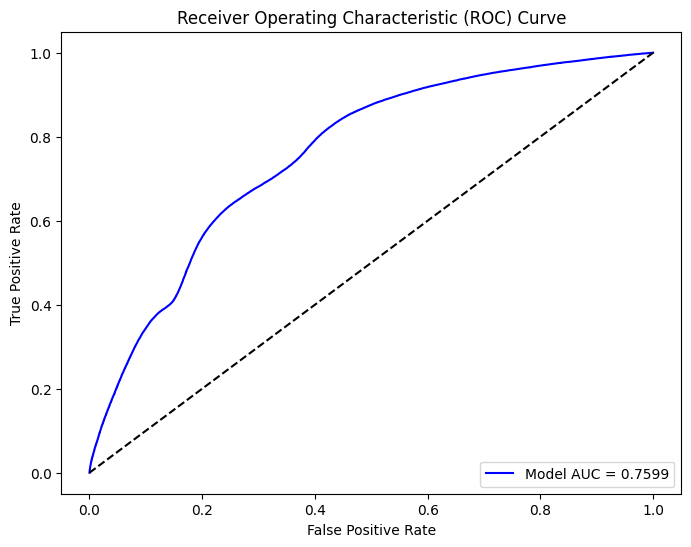

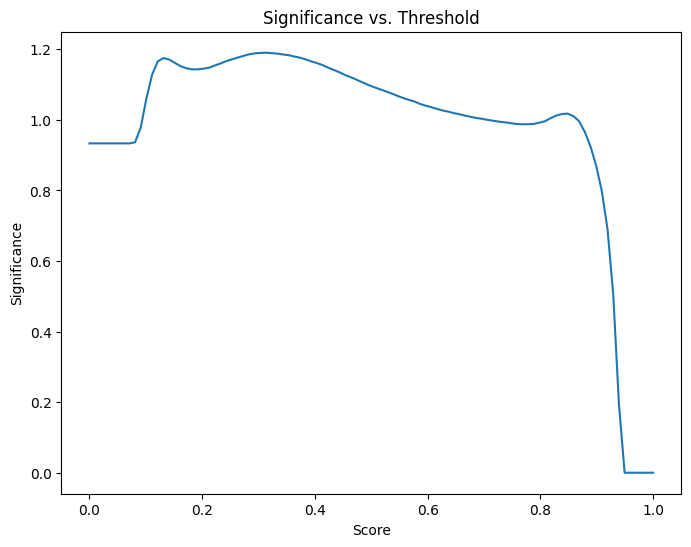

Max Significance: 1.1902

Plotting learning curves...


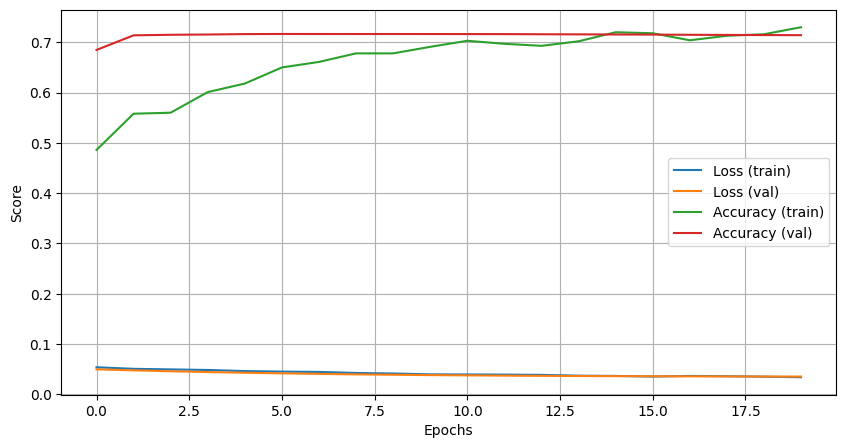


Plotting score distribution...
   6/8750 ━━━━━━━━━━━━━━━━━━━━ 1:38 11ms/step

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


8750/8750 ━━━━━━━━━━━━━━━━━━━━ 102s 12ms/step


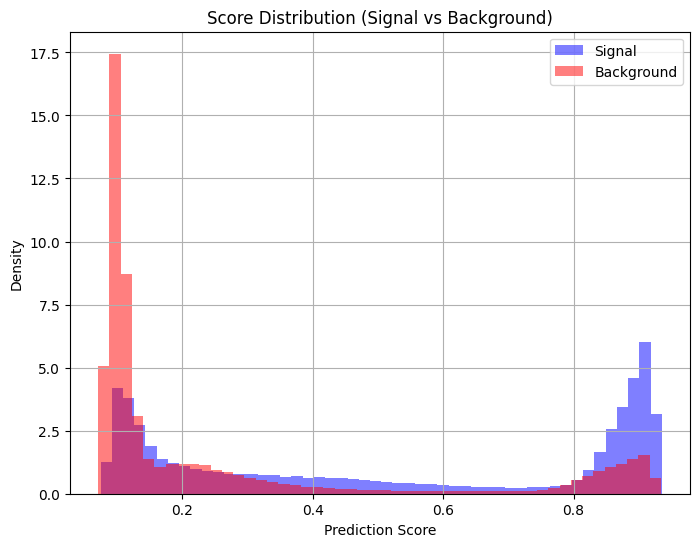

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# Predict on the test set
predictions = nn.predict(X_test, labels=y_test, weights=weights_test)

# Calculate AUC
auc = roc_auc_score(y_test, predictions, sample_weight=weights_test)
print(f"\nROC AUC Score: {auc:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, predictions, sample_weight=weights_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Model AUC = {auc:.4f}', color='blue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Calculate and Plot Significance
plt.figure(figsize=(8, 6))
max_significance = nn.significance()
plt.title('Significance vs. Threshold')
plt.show()

print(f"Max Significance: {max_significance:.4f}")
# Plot learning curves
print("\nPlotting learning curves...")
nn.plot_learning_curves()

# Plot score distribution
print("\nPlotting score distribution...")
nn.plot_score_distribution(X_test, y_test)


### Save and Load the Model

In [ ]:
import tensorflow as tf

def save(model, scaler, model_str, scaler_str):
    """Saves a Keras model and a StandardScaler object."""
    model.save(model_str)
    joblib.dump(scaler, scaler_str)

def load(model_str, scaler_str):
    """Loads a Keras model and a StandardScaler object."""
    loaded_model = tf.keras.models.load_model(model_str)
    loaded_scaler = joblib.load(scaler_str)
    return loaded_model, loaded_scaler

# Specify the models directory inside sample_code_submission
model_dir = "models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Test class-based save/load
print("Testing class methods:")
nn.save_model(model_dir)

# Fix: Provide n_dim to ensure the model is initialized before loading.
# X_test.shape[1] contains the correct number of input features (31).
nn_loaded = NeuralNetwork(n_dim=X_test.shape[1])
nn_loaded.load_model(model_dir)
print("Model loaded successfully via class method.\n")

# Test standalone save/load functions
print("Testing standalone functions:")
model_path_str = os.path.join(model_dir, "model.keras")
scaler_path_str = os.path.join(model_dir, "scaler.pkl")
save(nn.model, nn.scaler, model_str=model_path_str, scaler_str=scaler_path_str)
loaded_model, loaded_scaler = load(model_str=model_path_str, scaler_str=scaler_path_str)
print("Model loaded successfully via standalone functions.")